In [1]:
import polars as pl
import powerlaw

In [3]:
df_all = pl.read_csv('../data/all_repositories.csv', has_header=False, new_columns=['name', 'stars', 'watchers', 'branch', 'created_at', 'last_updated','fork','size','language','license'])
df_all = df_all.filter(pl.col("stars") >= 300)
unique_count = df_all['name'].n_unique()
print("All repositories:", unique_count)

All repositories: 173806


In [4]:
df_rust = pl.read_csv('../data/rust_repositories.csv', has_header=False, new_columns=['language', 'name', 'stars', 'rust_percentage', 'language_data'])
df_rust = df_rust.filter(pl.col("stars") >= 300)
df_rust = df_rust.join(df_all, on=["name"], how="left", suffix="_all")
df_rust = df_rust.unique(subset=["name"], keep="first")
print("Repositories with Rust code:", df_rust['name'].n_unique())
print("Repository with 1% or more Rust code:", df_rust.filter(pl.col("rust_percentage") >= 1)['name'].n_unique())

Repositories with Rust code: 6509
Repository with 1% or more Rust code: 5786


In [5]:
def fit_pl(np_array, name):
    dist = powerlaw.Fit(np_array, discrete=True, xmin=300, verbose=0)
    R_ln, p_ln = dist.distribution_compare('power_law', 'lognormal', normalized_ratio=True)

    return f"[{name}], [{len(np_array)}], [${dist.power_law.alpha:.3f} plus.minus {dist.power_law.sigma:.3f}$], [{dist.power_law.D:.3f}], [{dist.lognormal.mu:.3f}], [{dist.lognormal.sigma:.3f}], [{dist.lognormal.D:.3f}], [{R_ln:.3f}], [{p_ln:.3f}],"

texts = []

df_no_rust = df_all.unique(subset=["name"], keep="first").filter(
    ~pl.col("name").is_in(df_rust["name"].implode())
)
texts.append(fit_pl(df_no_rust.filter(pl.col("stars") > 0)["stars"].to_numpy(), "$l_\"rust\"=0$"))

PERCENTAGES = [(0.0, 0.1), (0.1, 0.2), (0.2, 0.3), (0.3, 0.4), (0.4, 0.5), (0.5, 0.6), (0.6, 0.7), (0.7, 0.8), (0.8, 0.9), (0.9, 1.0)]

for p in PERCENTAGES:
    from_percentage = p[0]
    to_percentage = p[1]
    subset = df_rust.filter(pl.col("rust_percentage") >= from_percentage * 100).filter(pl.col("rust_percentage") < to_percentage * 100)
    texts.append(fit_pl(subset.filter(pl.col("stars") > 0)["stars"].to_numpy(), f"${from_percentage:.1f}<=l_\"rust\"<{to_percentage:.1f}$"))

df_100_rust = df_rust.filter(pl.col("rust_percentage") == 100)
texts.append(fit_pl(df_100_rust.filter(pl.col("stars") > 0)["stars"].to_numpy(), "$l_\"rust\"=1$"))

df_any_rust = df_all.unique(subset=["name"], keep="first").filter(
    pl.col("name").is_in(df_rust["name"].implode())
)
texts.append(fit_pl(df_any_rust.filter(pl.col("stars") > 0)["stars"].to_numpy(), "$l_\"rust\">0$"))

for text in texts:
    print(f"    {text}")

    [$l_"rust"=0$], [167314], [$1.954 plus.minus 0.002$], [0.021], [-0.216], [2.865], [0.006], [-24.698], [0.000],
    [$0.0<=l_"rust"<0.1$], [1324], [$1.649 plus.minus 0.018$], [0.060], [4.411], [2.434], [0.025], [-5.214], [0.000],
    [$0.1<=l_"rust"<0.2$], [209], [$1.771 plus.minus 0.053$], [0.054], [0.287], [3.169], [0.033], [-1.108], [0.268],
    [$0.2<=l_"rust"<0.3$], [181], [$1.754 plus.minus 0.056$], [0.104], [5.531], [1.739], [0.039], [-2.361], [0.018],
    [$0.3<=l_"rust"<0.4$], [129], [$1.673 plus.minus 0.059$], [0.095], [4.603], [2.298], [0.042], [-1.695], [0.090],
    [$0.4<=l_"rust"<0.5$], [143], [$1.790 plus.minus 0.066$], [0.067], [3.740], [2.283], [0.053], [-1.561], [0.119],
    [$0.5<=l_"rust"<0.6$], [186], [$1.784 plus.minus 0.058$], [0.068], [-18.994], [5.883], [0.077], [-0.402], [0.688],
    [$0.6<=l_"rust"<0.7$], [195], [$1.794 plus.minus 0.057$], [0.039], [-22.034], [6.164], [0.042], [-0.357], [0.721],
    [$0.7<=l_"rust"<0.8$], [281], [$1.756 plus.minus 0.045$],

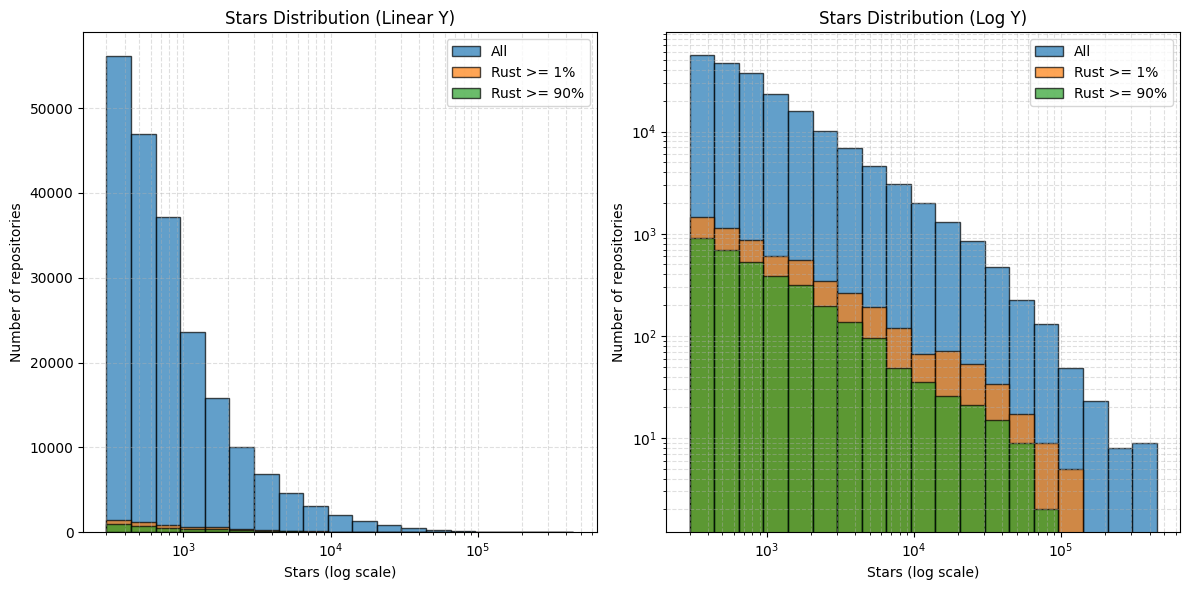

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl

# 1. Clean data using a reusable expression
# This avoids repeating the fill_null/cast/clip logic
clean_stars = pl.col("stars").fill_null(0).cast(pl.Int64).clip(lower_bound=1)

stars = df_all.select(clean_stars).to_series()
rust_stars_1 = df_rust.filter(pl.col("rust_percentage") >= 1).select(clean_stars).to_series()
rust_stars_2 = df_rust.filter(pl.col("rust_percentage") >= 90).select(clean_stars).to_series()

# 2. Setup Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True)
bins = np.logspace(np.log10(stars.min()), np.log10(stars.max() + 1), 20)

# 3. Plot logic in a clean loop
for i, ax in enumerate(axes):
    ax.hist(stars, bins=bins, edgecolor='black', label='All', alpha=0.7)
    ax.hist(rust_stars_1, bins=bins, color='C1', edgecolor='black', label='Rust >= 1%', alpha=0.7)
    ax.hist(rust_stars_2, bins=bins, color='C2', edgecolor='black', label='Rust >= 90%', alpha=0.7)
    
    # Common formatting
    ax.set_xscale('log')
    ax.set_xlabel('Stars (log scale)')
    ax.set_ylabel('Number of repositories')
    ax.grid(True, which='both', ls='--', alpha=0.4)
    ax.legend()
    
    if i == 0:
        ax.set_title('Stars Distribution (Linear Y)')
    else:
        ax.set_yscale('log')
        ax.set_title('Stars Distribution (Log Y)')

plt.tight_layout()
plt.show()